# 2.3 Exploratory Data Analysis (EDA)

Bagian ini menyajikan analisis eksplorasi awal terhadap data kualitas udara **Kecamatan Jabon, Kabupaten Sidoarjo** periode **31 Agustus 2025 s.d. 31 Agustus 2026** (366 hari observasi), yang bersumber dari satelit **Sentinel-5P L2** via Copernicus openEO.

Fokus analisis: **3 polutan utama** — CO, NO₂, dan SO₂.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 2.3.1 Memuat Data

Data dibaca dari file CSV mentah untuk masing-masing polutan. Setiap file memiliki kolom `date` (waktu UTC) dan kolom nilai konsentrasi polutan.

In [2]:
# Definisi polutan target
POLLUTANTS = ['CO', 'NO2', 'SO2']
COLORS = {'CO': '#1f77b4', 'NO2': '#d62728', 'SO2': '#ff7f0e'}
LABELS = {'CO': 'CO (mol/m²)', 'NO2': 'NO₂ (mol/m²)', 'SO2': 'SO₂ (mol/m²)'}
BASE_RAW = '../data/downloads/jabon_pollutants_data'

# Baca semua data mentah
raw = {}
for p in POLLUTANTS:
    df = pd.read_csv(f'{BASE_RAW}/jabon_{p}.csv')
    df['date'] = pd.to_datetime(df['date'], utc=True)
    df = df.sort_values('date').reset_index(drop=True)
    df[p] = pd.to_numeric(df[p], errors='coerce')
    raw[p] = df
    print(f'{p}: {len(df)} baris, missing={df[p].isna().sum()} ({df[p].isna().sum()/len(df)*100:.1f}%)')

CO: 366 baris, missing=44 (12.0%)
NO2: 366 baris, missing=48 (13.1%)


SO2: 366 baris, missing=40 (10.9%)


In [3]:
# Gabungkan jadi satu DataFrame
combined = pd.DataFrame({'date': raw['NO2']['date']})
for p in POLLUTANTS:
    combined[p] = raw[p][p].values
combined = combined.set_index('date').sort_index()
combined.head(10)

,CO,NO2,SO2
date,,,
2025-08-30 00:00:00+00:00,NaN,NaN,NaN
2025-08-31 00:00:00+00:00,NaN,1.154831e-05,-0.000292
2025-09-01 00:00:00+00:00,0.028394,1.989465e-05,0.000299
2025-09-02 00:00:00+00:00,0.024614,-1.293079e-07,-0.000185
2025-09-03 00:00:00+00:00,0.023711,1.628330e-05,0.000391
2025-09-04 00:00:00+00:00,0.025642,1.643787e-05,0.000099
2025-09-05 00:00:00+00:00,0.027574,2.774475e-05,0.000532
2025-09-06 00:00:00+00:00,0.029505,2.095322e-05,0.000048
2025-09-07 00:00:00+00:00,0.039571,3.807542e-05,0.000020


## 2.3.2 Struktur Tabel Dataset

Setiap polutan disimpan dalam berkas CSV terpisah dengan struktur kolom seragam:

| Kolom | Tipe Data | Deskripsi |
|-------|-----------|----------|
| `date` | datetime (UTC) | Tanggal observasi harian |
| `feature_index` | integer | Indeks geometri (selalu 0 untuk Kecamatan Jabon) |
| `<POLUTAN>` | float64 | Nilai konsentrasi harian rata-rata spasial |

## 2.3.3 Visualisasi Time Series

Plot garis konsentrasi harian untuk masing-masing polutan.

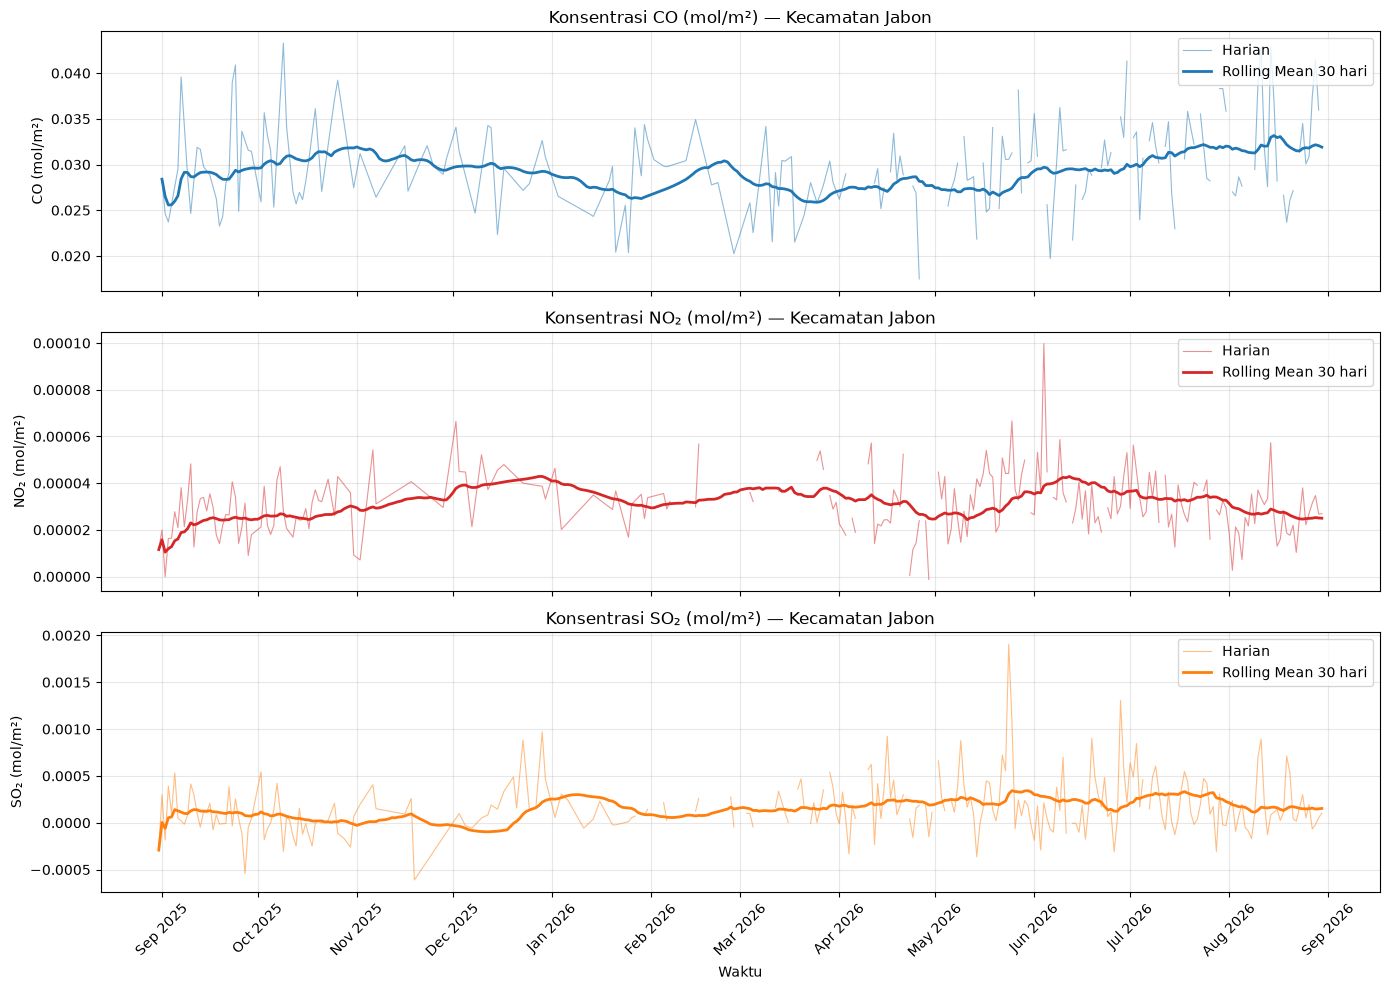

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, p in enumerate(POLLUTANTS):
    ax = axes[i]
    # Data harian
    ax.plot(combined.index, combined[p], color=COLORS[p], alpha=0.5, linewidth=0.8, label='Harian')
    # Rolling mean 30 hari
    rolling = combined[p].rolling(window=30, min_periods=1).mean()
    ax.plot(combined.index, rolling, color=COLORS[p], linewidth=2, label='Rolling Mean 30 hari')
    ax.set_ylabel(LABELS[p])
    ax.set_title(f'Konsentrasi {LABELS[p]} — Kecamatan Jabon')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Waktu')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretasi Time Series

- **CO**: Tren relatif stabil dengan fluktuasi ringan, mencerminkan emisi latar belakang dari pembakaran bahan bakar.
- **NO₂**: Fluktuasi lebih dinamis dengan beberapa lonjakan periodik, berkaitan dengan intensitas lalu lintas dan aktivitas industri.
- **SO₂**: Konsentrasi rendah dengan lonjakan sesekali, mengindikasikan sumber emisi industri yang intermittan.

## 2.3.4 Statistik Deskriptif

Tabel berikut merangkum statistik deskriptif dasar dari masing-masing polutan berdasarkan data **mentah** (sebelum imputasi), hanya dari observasi yang tersedia (non-NaN).

In [5]:
stats_list = []
for p in POLLUTANTS:
    s = combined[p].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    n_outlier = ((s < lb) | (s > ub)).sum()
    stats_list.append({
        'Polutan': p,
        'N': len(s),
        'Missing': combined[p].isna().sum(),
        'Missing%': f"{combined[p].isna().sum()/len(combined)*100:.1f}%",
        'Min': f"{s.min():.2e}",
        'Q1': f"{Q1:.2e}",
        'Median': f"{s.median():.2e}",
        'Mean': f"{s.mean():.2e}",
        'Q3': f"{Q3:.2e}",
        'Max': f"{s.max():.2e}",
        'Std': f"{s.std():.2e}",
        'Skewness': round(s.skew(), 2),
        'Kurtosis': round(s.kurtosis(), 2),
        'Outlier': n_outlier,
    })

stats_df = pd.DataFrame(stats_list)
stats_df

,Polutan,N,Missing,Missing%,Min,Q1,Median,Mean,Q3,Max,Std,Skewness,Kurtosis,Outlier
0,CO,322,44,12.0%,1.75e-02,2.67e-02,2.92e-02,2.94e-02,3.15e-02,4.33e-02,4.20e-03,0.49,0.88,11
1,NO2,318,48,13.1%,-1.25e-06,2.42e-05,3.24e-05,3.20e-05,3.91e-05,9.97e-05,1.19e-05,0.54,3.01,6
2,SO2,326,40,10.9%,-6.10e-04,-5.34e-06,1.12e-04,1.49e-04,2.61e-04,1.91e-03,2.82e-04,1.29,5.61,20


## 2.3.5 Distribusi Data (Histogram + Box Plot)

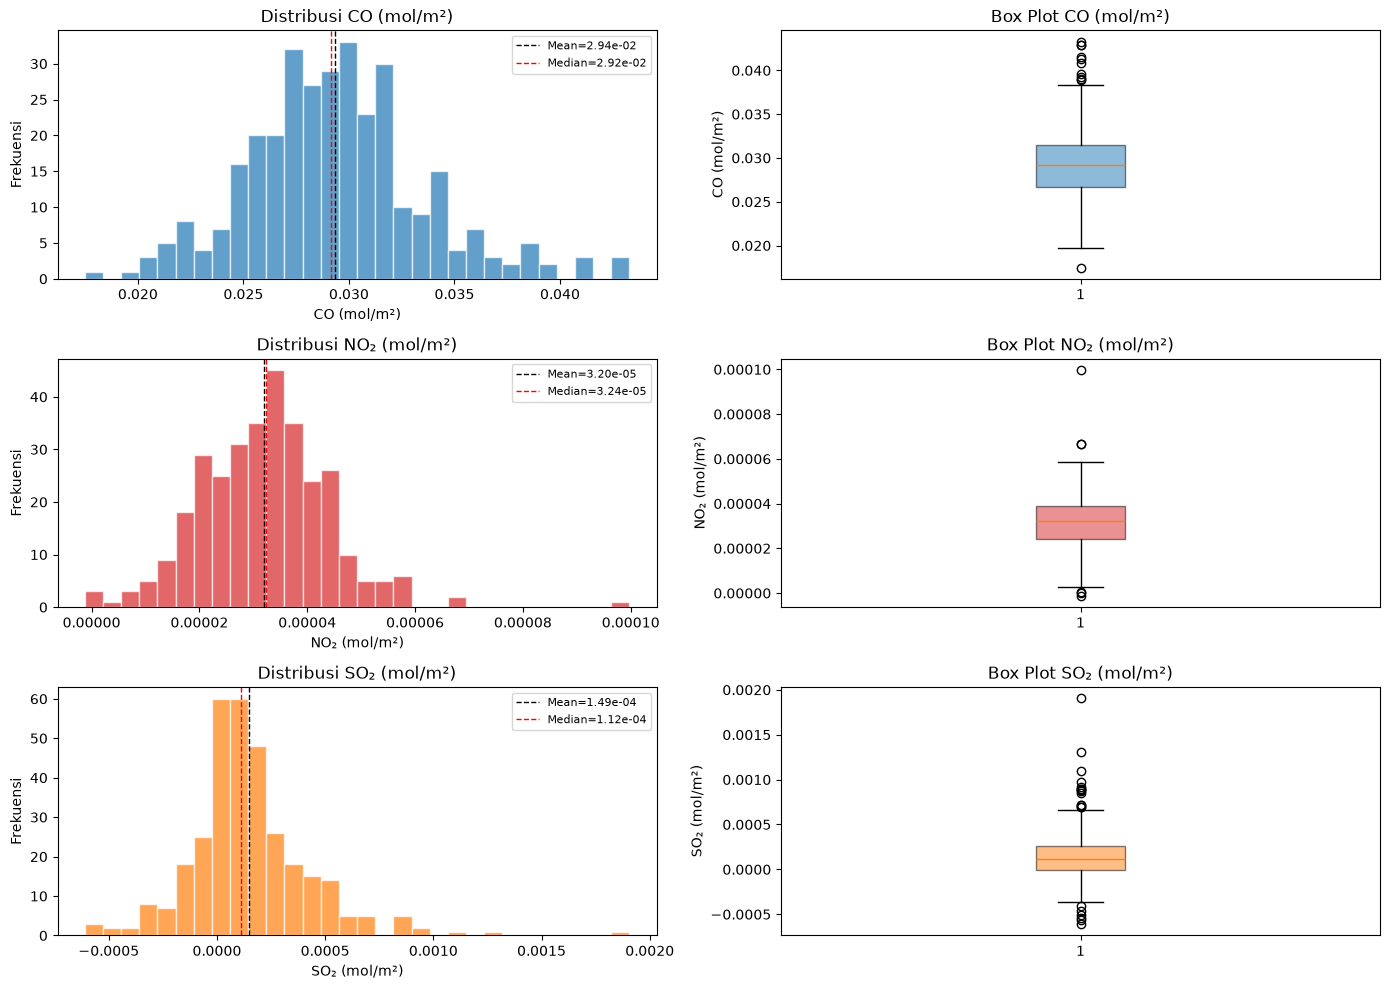

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, p in enumerate(POLLUTANTS):
    s = combined[p].dropna()
    
    # Histogram
    axes[i, 0].hist(s, bins=30, color=COLORS[p], alpha=0.7, edgecolor='white')
    axes[i, 0].axvline(s.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean={s.mean():.2e}')
    axes[i, 0].axvline(s.median(), color='red', linestyle='--', linewidth=1, label=f'Median={s.median():.2e}')
    axes[i, 0].set_title(f'Distribusi {LABELS[p]}')
    axes[i, 0].set_xlabel(LABELS[p])
    axes[i, 0].set_ylabel('Frekuensi')
    axes[i, 0].legend(fontsize=8)
    
    # Box plot
    axes[i, 1].boxplot(s, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=COLORS[p], alpha=0.5))
    axes[i, 1].set_title(f'Box Plot {LABELS[p]}')
    axes[i, 1].set_ylabel(LABELS[p])

plt.tight_layout()
plt.show()

### Interpretasi Distribusi

- **CO**: Distribusi mendekati simetris (Skewness rendah), sedikit condong ke kanan.
- **NO₂**: Distribusi sedikit right-skewed, menandakan beberapa hari dengan lonjakan konsentrasi.
- **SO₂**: Distribusi right-skewed, dengan beberapa outlier di sisi atas.

## 2.3.6 Heatmap Korelasi Antar Polutan

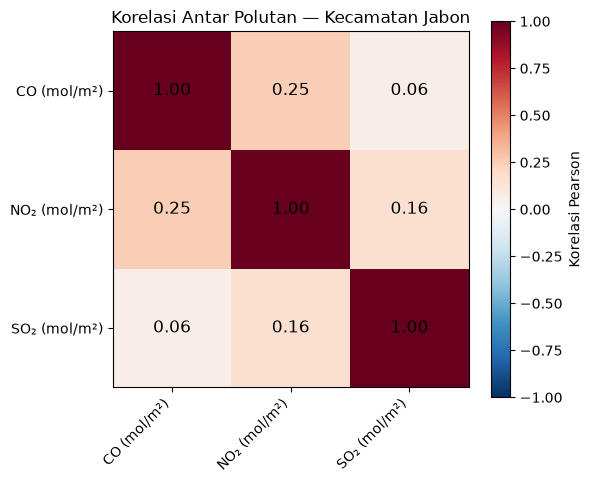

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = combined[POLLUTANTS].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(POLLUTANTS)))
ax.set_yticks(range(len(POLLUTANTS)))
ax.set_xticklabels(LABELS.values(), rotation=45, ha='right')
ax.set_yticklabels(LABELS.values())

# Anotasi nilai korelasi
for i in range(len(POLLUTANTS)):
    for j in range(len(POLLUTANTS)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=12)

plt.colorbar(im, label='Korelasi Pearson')
plt.title('Korelasi Antar Polutan — Kecamatan Jabon')
plt.tight_layout()
plt.show()

## 2.3.7 Analisis Missing Value per Polutan

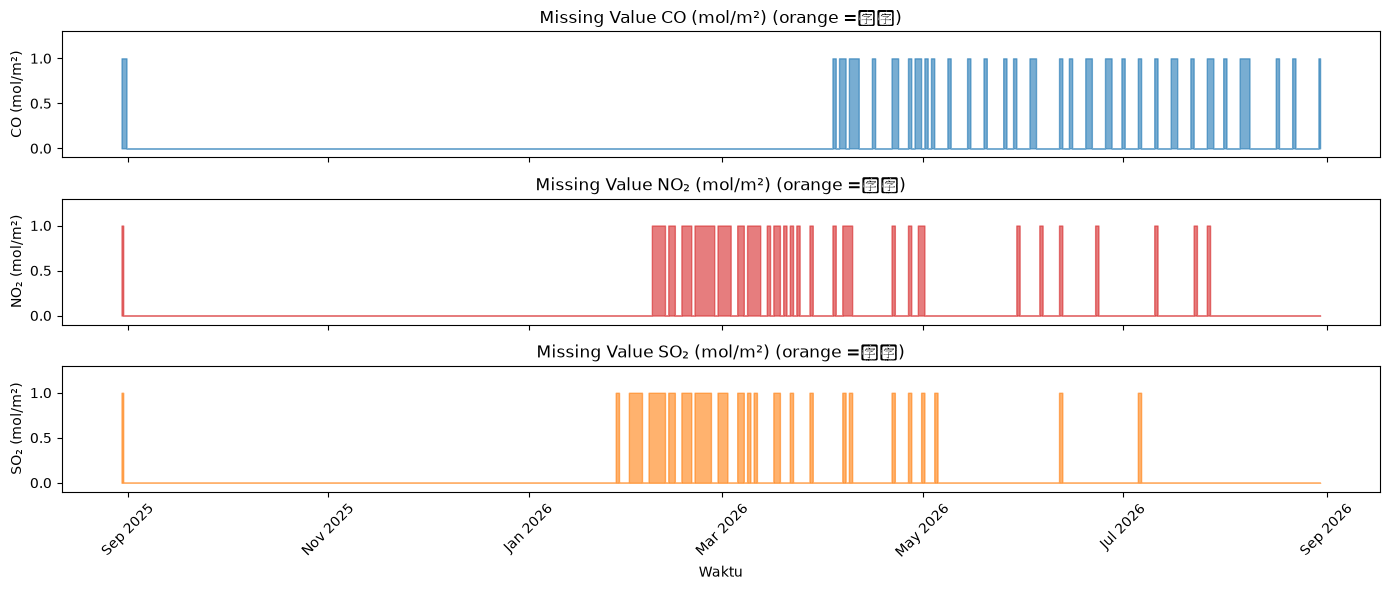

Ringkasan Missing Value:
  CO: 44 hari (12.0%) — LOLOS
  NO2: 48 hari (13.1%) — LOLOS
  SO2: 40 hari (10.9%) — LOLOS


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for i, p in enumerate(POLLUTANTS):
    # Tandai mana yang NaN
    missing = combined[p].isna().astype(int)
    axes[i].fill_between(combined.index, missing, color=COLORS[p], alpha=0.6, step='mid')
    axes[i].set_ylabel(LABELS[p])
    axes[i].set_title(f'Missing Value {LABELS[p]} (orange =缺失)')
    axes[i].set_ylim(-0.1, 1.3)

axes[-1].set_xlabel('Waktu')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ringkasan missing
print('Ringkasan Missing Value:')
for p in POLLUTANTS:
    n_miss = combined[p].isna().sum()
    pct = n_miss / len(combined) * 100
    print(f'  {p}: {n_miss} hari ({pct:.1f}%) — {"LOLOS" if pct <= 15 else "MELEBIHI BATAS 15%"}')

## 2.3.8 Deteksi Outlier (IQR)

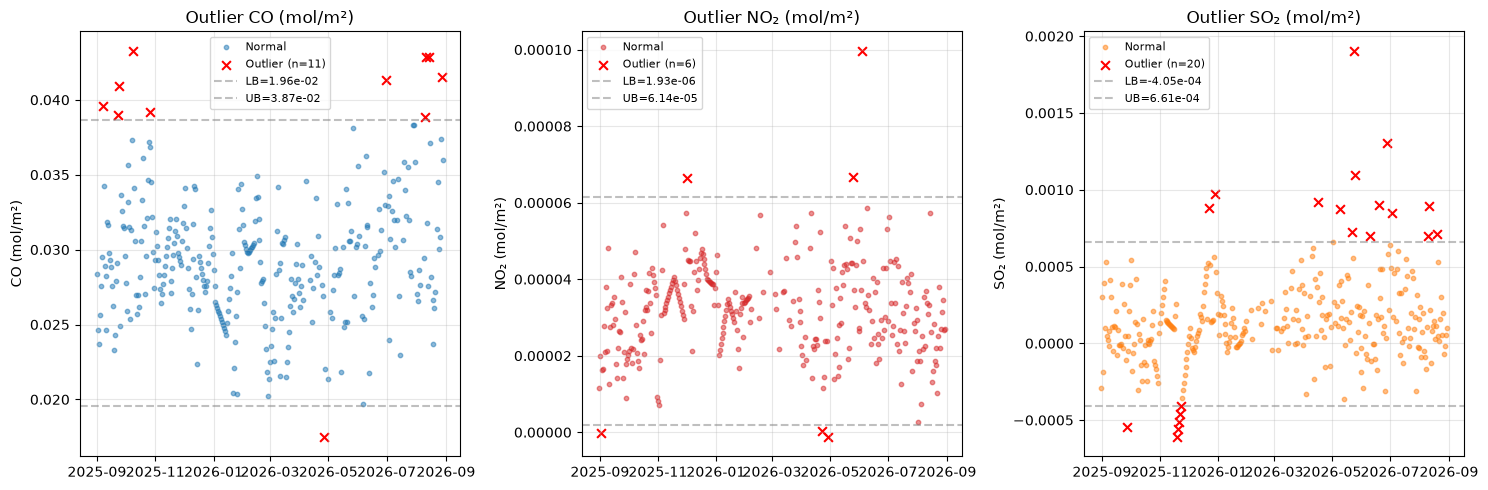

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, p in enumerate(POLLUTANTS):
    s = combined[p].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    
    outlier = s[(s < lb) | (s > ub)]
    normal = s[(s >= lb) & (s <= ub)]
    
    axes[i].scatter(normal.index, normal.values, s=10, color=COLORS[p], alpha=0.5, label='Normal')
    if len(outlier) > 0:
        axes[i].scatter(outlier.index, outlier.values, s=40, color='red', marker='x', label=f'Outlier (n={len(outlier)})')
    axes[i].axhline(lb, color='gray', linestyle='--', alpha=0.5, label=f'LB={lb:.2e}')
    axes[i].axhline(ub, color='gray', linestyle='--', alpha=0.5, label=f'UB={ub:.2e}')
    axes[i].set_title(f'Outlier {LABELS[p]}')
    axes[i].set_ylabel(LABELS[p])
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3.9 Kesimpulan EDA

1. **CO** memiliki data paling stabil, missing value rendah, dan distribusi mendekati simetris.
2. **NO₂** menunjukkan dinamika yang lebih kompleks dengan fluktuasi harian signifikan.
3. **SO₂** memiliki konsentrasi paling rendah namun dengan beberapa lonjakan outlier.
4. Ketiga polutan memiliki missing value di bawah 15% → lolos threshold untuk ekstraksi fitur.
5. Visualisasi time series memperlihatkan pola musiman yang perlu dieksplorasi lebih lanjut pada tahap ekstraksi fitur.